In [ ]:
import numpy as np
import torch
import torch.nn as nn
from sklearn.preprocessing import MinMaxScaler
from sklearn.model_selection import train_test_split
import matplotlib.pyplot as plt
import pandas as pd
import os

In [ ]:
torch.backends.quantized.engine = "fbgemm"

In [ ]:
print(torch.backends.quantized.engine)

fbgemm


In [ ]:
RANDOM_STATE = 42

In [ ]:
df1 = pd.read_csv("normal_metrics.csv")
df2 = pd.read_csv("sub_blurred_metrics.csv")
df3 = pd.read_csv("sub_cpu_stress_metrics.csv")

In [ ]:
cols_to_keep = ['latency_mean_ms', 'latency_std_ms', 'confidence_mean']

df1 = df1[cols_to_keep]
df2 = df2[cols_to_keep]
df3 = df3[cols_to_keep]

In [ ]:
def remove_outliers(df):
    Q1 = df.quantile(0.25)
    Q3 = df.quantile(0.75)
    IQR = Q3 - Q1
    filtered_df = df[~((df < (Q1 - 1.5 * IQR)) | (df > (Q3 + 1.5 * IQR))).any(axis=1)]
    return filtered_df

df1_clean = remove_outliers(df1)
df2_clean = remove_outliers(df2)
df3_clean = remove_outliers(df3)

print("df1_clean size:", df1_clean.shape)
print("df2_clean size:", df2_clean.shape)
print("df3_clean size:", df3_clean.shape)

df1_clean size: (3953, 3)
df2_clean size: (935, 3)
df3_clean size: (990, 3)


In [ ]:
train_normal = df1.sample(n=1600, random_state=RANDOM_STATE)

In [ ]:
train_anom_1 = df2.sample(n=800, random_state=RANDOM_STATE)
train_anom_2 = df3.sample(n=800, random_state=RANDOM_STATE)

In [ ]:
train_normal = train_normal.copy()
train_normal["label"] = 0

train_anom_1 = train_anom_1.copy()
train_anom_1["label"] = 1

train_anom_2 = train_anom_2.copy()
train_anom_2["label"] = 1

In [ ]:
train_data = pd.concat([train_normal, train_anom_1, train_anom_2], ignore_index=True)

In [ ]:
train_data = train_data.sample(frac=1, random_state=RANDOM_STATE).reset_index(drop=True)

In [ ]:
remaining_df1 = df1.drop(train_normal.index)
remaining_df2 = df2.drop(train_anom_1.index)
remaining_df3 = df3.drop(train_anom_2.index)

In [ ]:
test_normal = remaining_df1.sample(n=200, random_state=RANDOM_STATE)
test_anom_1 = remaining_df2.sample(n=100, random_state=RANDOM_STATE)
test_anom_2 = remaining_df3.sample(n=100, random_state=RANDOM_STATE)

In [ ]:
test_normal = test_normal.copy()
test_normal["label"] = 0

test_anom_1 = test_anom_1.copy()
test_anom_1["label"] = 1

test_anom_2 = test_anom_2.copy()
test_anom_2["label"] = 1

In [ ]:
test_final = pd.concat([test_normal, test_anom_1, test_anom_2], ignore_index=True)

In [ ]:
test_final = test_final.sample(frac=1, random_state=RANDOM_STATE).reset_index(drop=True)

In [ ]:
X_train = train_data.drop("label", axis=1).values
y_train = train_data["label"].values

In [ ]:
X_test = test_final.drop("label", axis=1).values
y_test = test_final["label"].values

In [ ]:
print("X_train shape:", X_train.shape)
print("X_test shape:", X_test.shape)
print("y_test shape:", y_test.shape)

X_train shape: (3200, 3)
X_test shape: (400, 3)
y_test shape: (400,)


In [ ]:
scaler = MinMaxScaler(feature_range=(-1, 1))
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [ ]:
X_train_tensor = torch.tensor(X_train, dtype=torch.float32)
y_train_tensor = torch.tensor(y_train, dtype=torch.float32).unsqueeze(1)  # (N,1)
X_test_tensor = torch.tensor(X_test, dtype=torch.float32)
y_test_tensor = torch.tensor(y_test, dtype=torch.float32).unsqueeze(1)

In [ ]:
class MLPClassifier(nn.Module):
    def __init__(self):
        super().__init__()
        self.fc1 = nn.Linear(3, 128)
        self.relu1 = nn.ReLU()
        self.fc2 = nn.Linear(128, 64)
        self.relu2 = nn.ReLU()
        self.fc3 = nn.Linear(64, 32)
        self.relu3 = nn.ReLU()
        self.fc4 = nn.Linear(32, 16)
        self.relu4 = nn.ReLU()
        self.fc5 = nn.Linear(16, 1)

    def forward(self, x):
        x = self.fc1(x)
        x = self.relu1(x)
        x = self.fc2(x)
        x = self.relu2(x)
        x = self.fc3(x)
        x = self.relu3(x)
        x = self.fc4(x)
        x = self.relu4(x)
        x = self.fc5(x)
        return x

In [ ]:
model = MLPClassifier()
criterion = nn.BCEWithLogitsLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)

In [ ]:
epochs = 300
batch_size = 64

dataset = torch.utils.data.TensorDataset(X_train_tensor, y_train_tensor)
loader = torch.utils.data.DataLoader(dataset, batch_size=batch_size, shuffle=True)

for epoch in range(epochs):
    model.train()
    running_loss = 0.0

    for X_batch, y_batch in loader:
        optimizer.zero_grad()

        outputs = model(X_batch)

        loss = criterion(
            outputs.view(-1),
            y_batch.view(-1).float()
        )

        loss.backward()
        optimizer.step()

        running_loss += loss.item()

    epoch_loss = running_loss / len(loader)
    print(f"Epoch [{epoch+1}/{epochs}] - Loss: {epoch_loss:.6f}")

Epoch [1/300] - Loss: 0.644232
Epoch [2/300] - Loss: 0.637158
Epoch [3/300] - Loss: 0.626529
Epoch [4/300] - Loss: 0.625420
Epoch [5/300] - Loss: 0.620669
Epoch [6/300] - Loss: 0.620572
Epoch [7/300] - Loss: 0.621044
Epoch [8/300] - Loss: 0.617373
Epoch [9/300] - Loss: 0.618094
Epoch [10/300] - Loss: 0.617918
Epoch [11/300] - Loss: 0.612838
Epoch [12/300] - Loss: 0.611363
Epoch [13/300] - Loss: 0.612118
Epoch [14/300] - Loss: 0.606987
Epoch [15/300] - Loss: 0.606418
Epoch [16/300] - Loss: 0.601905
Epoch [17/300] - Loss: 0.598967
Epoch [18/300] - Loss: 0.591550
Epoch [19/300] - Loss: 0.596644
Epoch [20/300] - Loss: 0.579690
Epoch [21/300] - Loss: 0.589056
Epoch [22/300] - Loss: 0.549519
Epoch [23/300] - Loss: 0.570138
Epoch [24/300] - Loss: 0.527432
Epoch [25/300] - Loss: 0.515523
Epoch [26/300] - Loss: 0.452146
Epoch [27/300] - Loss: 0.415857
Epoch [28/300] - Loss: 0.411585
Epoch [29/300] - Loss: 0.381032
Epoch [30/300] - Loss: 0.363566
Epoch [31/300] - Loss: 0.350753
Epoch [32/300] - 

In [ ]:
import numpy as np
from sklearn.metrics import f1_score

def find_best_threshold(model, X_tensor, y_tensor, metric='f1', thresholds=np.arange(0, 1, 0.01)):
    model.eval()
    with torch.no_grad():
        logits = model(X_tensor).view(-1)
        probs = torch.sigmoid(logits).cpu().numpy()
    y_true = y_tensor.view(-1).cpu().numpy()

    best_thresh = 0.5
    best_score = 0

    for thresh in thresholds:
        preds = (probs > thresh).astype(int)
        if metric == 'f1':
            score = f1_score(y_true, preds)
        elif metric == 'accuracy':
            from sklearn.metrics import accuracy_score
            score = accuracy_score(y_true, preds)
        else:
            raise ValueError("Unsupported metric")
        if score > best_score:
            best_score = score
            best_thresh = thresh

    return best_thresh, best_score

best_threshold, best_f1 = find_best_threshold(
    model,
    X_test_tensor,
    y_test_tensor,
    metric='f1'
)

print(f"Best threshold: {best_threshold:.2f}, Best F1-score: {best_f1:.4f}")


Best threshold: 0.41, Best F1-score: 0.9507


Test Accuracy: 95.00%
Confusion Matrix:
[[187  13]
 [  7 193]]


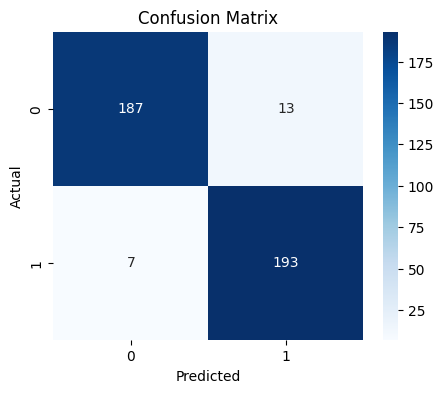

Classification Report:
               precision    recall  f1-score   support

      Normal       0.96      0.94      0.95       200
     Anomaly       0.94      0.96      0.95       200

    accuracy                           0.95       400
   macro avg       0.95      0.95      0.95       400
weighted avg       0.95      0.95      0.95       400



In [ ]:
import torch
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

model.eval()
with torch.no_grad():
    logits = model(X_test_tensor)
    probs = torch.sigmoid(logits)
    y_pred = (probs > best_threshold).int()

acc = accuracy_score(y_test_tensor.numpy(), y_pred.numpy())
print(f"Test Accuracy: {acc*100:.2f}%")

cm = confusion_matrix(y_test_tensor.numpy(), y_pred.numpy())
print("Confusion Matrix:")
print(cm)

import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(5,4))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.show()

report = classification_report(y_test_tensor.numpy(), y_pred.numpy(), target_names=["Normal", "Anomaly"])
print("Classification Report:\n", report)

In [ ]:
torch.save(model.state_dict(), "mlp_model_fp32.pth")
print('Size (KB):', os.path.getsize("mlp_model_fp32.pth")/1e3)

Size (KB): 49.845


In [ ]:
print("fc1 weights:", model.fc1.weight)
print("fc1 bias:", model.fc1.bias)

fc1 weights: Parameter containing:
tensor([[ 4.2029e-01,  1.6644e-01, -3.4411e+00],
        [-1.8403e-01, -2.6824e-01,  4.2763e-01],
        [-1.3345e-01, -2.5261e-01, -2.1534e-01],
        [-2.2710e-01,  1.1708e-01,  5.2552e-01],
        [ 1.1509e-01,  2.8453e-03,  3.4525e+00],
        [-2.8143e-01,  1.4400e-01,  1.6082e-02],
        [ 1.5753e-01, -2.6469e-01,  4.8512e-03],
        [-2.3663e-01, -4.0869e-01, -6.6389e-02],
        [-1.6755e-01,  5.0446e-01,  3.9707e+00],
        [ 7.9262e-02,  3.7598e-01,  4.3236e+00],
        [ 3.2858e-01,  3.1077e-01,  3.4683e+00],
        [-3.3744e-01, -4.1705e-01, -2.8451e-01],
        [-5.7002e-01, -4.9375e-01,  5.6120e-01],
        [-4.9087e-01,  4.1484e-01, -4.8643e-01],
        [-2.3439e-01, -4.2910e-01, -1.7932e-01],
        [-2.8088e-02,  4.6937e-01, -3.8143e+00],
        [-4.9507e-01, -5.1617e-01, -8.0345e-03],
        [ 2.0829e-01, -4.4527e-01,  1.0127e+00],
        [-3.8503e-01,  2.7011e-01, -1.3363e-02],
        [ 1.0054e-02,  1.4998e-01,

In [ ]:
import torch
import torch.nn as nn
import torch.ao.quantization as quant

class QuantisedMLPClassifier(nn.Module):
    def __init__(self):
        super().__init__()

        self.quant = quant.QuantStub()
        self.dequant = quant.DeQuantStub()

        self.fc1 = nn.Linear(3, 128)
        self.relu1 = nn.ReLU()

        self.fc2 = nn.Linear(128, 64)
        self.relu2 = nn.ReLU()

        self.fc3 = nn.Linear(64, 32)
        self.relu3 = nn.ReLU()

        self.fc4 = nn.Linear(32, 16)
        self.relu4 = nn.ReLU()

        self.fc5 = nn.Linear(16, 1)

    def forward(self, x):
        x = self.fc1(x)
        x = self.relu1(x)

        x = self.quant(x)

        x = self.fc2(x)
        x = self.relu2(x)
        x = self.fc3(x)
        x = self.relu3(x)
        x = self.fc4(x)
        x = self.relu4(x)

        x = self.dequant(x)

        x = self.fc5(x)
        return x

In [ ]:
quantized_model = QuantisedMLPClassifier()
quantized_model.load_state_dict(torch.load("mlp_model_fp32.pth"), strict=False)
quantized_model.train()

QuantisedMLPClassifier(
  (quant): QuantStub()
  (dequant): DeQuantStub()
  (fc1): Linear(in_features=3, out_features=128, bias=True)
  (relu1): ReLU()
  (fc2): Linear(in_features=128, out_features=64, bias=True)
  (relu2): ReLU()
  (fc3): Linear(in_features=64, out_features=32, bias=True)
  (relu3): ReLU()
  (fc4): Linear(in_features=32, out_features=16, bias=True)
  (relu4): ReLU()
  (fc5): Linear(in_features=16, out_features=1, bias=True)
)

In [ ]:
torch.ao.quantization.fuse_modules(
    quantized_model,
    [['fc2', 'relu2'],
     ['fc3', 'relu3'],
     ['fc4', 'relu4']],
    inplace=True
)

QuantisedMLPClassifier(
  (quant): QuantStub()
  (dequant): DeQuantStub()
  (fc1): Linear(in_features=3, out_features=128, bias=True)
  (relu1): ReLU()
  (fc2): LinearReLU(
    (0): Linear(in_features=128, out_features=64, bias=True)
    (1): ReLU()
  )
  (relu2): Identity()
  (fc3): LinearReLU(
    (0): Linear(in_features=64, out_features=32, bias=True)
    (1): ReLU()
  )
  (relu3): Identity()
  (fc4): LinearReLU(
    (0): Linear(in_features=32, out_features=16, bias=True)
    (1): ReLU()
  )
  (relu4): Identity()
  (fc5): Linear(in_features=16, out_features=1, bias=True)
)

In [ ]:
quantized_model.qconfig = None

qconfig = quant.get_default_qat_qconfig("fbgemm")

quantized_model.fc2.qconfig = qconfig
quantized_model.fc3.qconfig = qconfig
quantized_model.fc4.qconfig = qconfig
quantized_model.quant.qconfig = qconfig
quantized_model.dequant.qconfig = qconfig

In [ ]:
torch.ao.quantization.prepare_qat(quantized_model, inplace=True)

/tmp/ipython-input-249/3331471813.py:1: DeprecationWarning: torch.ao.quantization is deprecated and will be removed in 2.10. 
For migrations of users: 
1. Eager mode quantization (torch.ao.quantization.quantize, torch.ao.quantization.quantize_dynamic), please migrate to use torchao eager mode quantize_ API instead 
2. FX graph mode quantization (torch.ao.quantization.quantize_fx.prepare_fx,torch.ao.quantization.quantize_fx.convert_fx, please migrate to use torchao pt2e quantization API instead (prepare_pt2e, convert_pt2e) 
3. pt2e quantization has been migrated to torchao (https://github.com/pytorch/ao/tree/main/torchao/quantization/pt2e) 
see https://github.com/pytorch/ao/issues/2259 for more details
  torch.ao.quantization.prepare_qat(quantized_model, inplace=True)
/usr/local/lib/python3.12/dist-packages/torch/ao/quantization/observer.py:534: UserWarning: Please use quant_min and quant_max to specify the range for observers.                     reduce_range will be deprecated in a fu

QuantisedMLPClassifier(
  (quant): QuantStub(
    (activation_post_process): FusedMovingAvgObsFakeQuantize(
      fake_quant_enabled=tensor([1]), observer_enabled=tensor([1]), scale=tensor([1.]), zero_point=tensor([0], dtype=torch.int32), dtype=torch.quint8, quant_min=0, quant_max=127, qscheme=torch.per_tensor_affine, reduce_range=True
      (activation_post_process): MovingAverageMinMaxObserver(min_val=inf, max_val=-inf)
    )
  )
  (dequant): DeQuantStub()
  (fc1): Linear(in_features=3, out_features=128, bias=True)
  (relu1): ReLU()
  (fc2): LinearReLU(
    in_features=128, out_features=64, bias=True
    (weight_fake_quant): FusedMovingAvgObsFakeQuantize(
      fake_quant_enabled=tensor([1]), observer_enabled=tensor([1]), scale=tensor([1.]), zero_point=tensor([0], dtype=torch.int32), dtype=torch.qint8, quant_min=-128, quant_max=127, qscheme=torch.per_channel_symmetric, reduce_range=False
      (activation_post_process): MovingAveragePerChannelMinMaxObserver(min_val=tensor([]), max_va

In [ ]:
freeze_observer_epoch = 5
disable_fake_quant_epoch = 25
epochs = 30

for epoch in range(epochs):
    quantized_model.train()
    running_loss = 0.0

    if epoch == freeze_observer_epoch:
        quantized_model.apply(torch.ao.quantization.disable_observer)
        print("Observers frozen")

    if epoch == disable_fake_quant_epoch:
        quantized_model.apply(torch.ao.quantization.disable_fake_quant)
        print("Fake quant disabled")

    for X_batch, y_batch in loader:
        optimizer.zero_grad()
        outputs = quantized_model(X_batch)
        loss = criterion(outputs.view(-1), y_batch.view(-1).float())
        loss.backward()
        optimizer.step()
        running_loss += loss.item()

    epoch_loss = running_loss / len(loader)
    print(f"Epoch [{epoch+1}/{epochs}] - Loss: {epoch_loss:.6f}")

Epoch [1/30] - Loss: 0.163318
Epoch [2/30] - Loss: 0.162072
Epoch [3/30] - Loss: 0.163698
Epoch [4/30] - Loss: 0.160922
Epoch [5/30] - Loss: 0.161481
Observers frozen
Epoch [6/30] - Loss: 0.157960
Epoch [7/30] - Loss: 0.157960
Epoch [8/30] - Loss: 0.157960
Epoch [9/30] - Loss: 0.157960
Epoch [10/30] - Loss: 0.157960
Epoch [11/30] - Loss: 0.157960
Epoch [12/30] - Loss: 0.157960
Epoch [13/30] - Loss: 0.157960
Epoch [14/30] - Loss: 0.157960
Epoch [15/30] - Loss: 0.157960
Epoch [16/30] - Loss: 0.157960
Epoch [17/30] - Loss: 0.157960
Epoch [18/30] - Loss: 0.157960
Epoch [19/30] - Loss: 0.157960
Epoch [20/30] - Loss: 0.157960
Epoch [21/30] - Loss: 0.157960
Epoch [22/30] - Loss: 0.157960
Epoch [23/30] - Loss: 0.157960
Epoch [24/30] - Loss: 0.157960
Epoch [25/30] - Loss: 0.157960
Fake quant disabled
Epoch [26/30] - Loss: 0.151477
Epoch [27/30] - Loss: 0.151477
Epoch [28/30] - Loss: 0.151477
Epoch [29/30] - Loss: 0.151477
Epoch [30/30] - Loss: 0.151477


In [ ]:
quantized_model_int8 = torch.ao.quantization.convert(
    quantized_model.eval(), inplace=False
)

/tmp/ipython-input-249/865720354.py:1: DeprecationWarning: torch.ao.quantization is deprecated and will be removed in 2.10. 
For migrations of users: 
1. Eager mode quantization (torch.ao.quantization.quantize, torch.ao.quantization.quantize_dynamic), please migrate to use torchao eager mode quantize_ API instead 
2. FX graph mode quantization (torch.ao.quantization.quantize_fx.prepare_fx,torch.ao.quantization.quantize_fx.convert_fx, please migrate to use torchao pt2e quantization API instead (prepare_pt2e, convert_pt2e) 
3. pt2e quantization has been migrated to torchao (https://github.com/pytorch/ao/tree/main/torchao/quantization/pt2e) 
see https://github.com/pytorch/ao/issues/2259 for more details
  quantized_model_int8 = torch.ao.quantization.convert(


In [ ]:
print(quantized_model_int8)

QuantisedMLPClassifier(
  (quant): Quantize(scale=tensor([1.0131]), zero_point=tensor([0]), dtype=torch.quint8)
  (dequant): DeQuantize()
  (fc1): Linear(in_features=3, out_features=128, bias=True)
  (relu1): ReLU()
  (fc2): QuantizedLinearReLU(in_features=128, out_features=64, scale=0.4840630888938904, zero_point=0, qscheme=torch.per_channel_affine)
  (relu2): Identity()
  (fc3): QuantizedLinearReLU(in_features=64, out_features=32, scale=0.10093289613723755, zero_point=0, qscheme=torch.per_channel_affine)
  (relu3): Identity()
  (fc4): QuantizedLinearReLU(in_features=32, out_features=16, scale=0.06871240586042404, zero_point=0, qscheme=torch.per_channel_affine)
  (relu4): Identity()
  (fc5): Linear(in_features=16, out_features=1, bias=True)
)


Test Accuracy: 94.50%
Confusion Matrix:
[[184  16]
 [  6 194]]


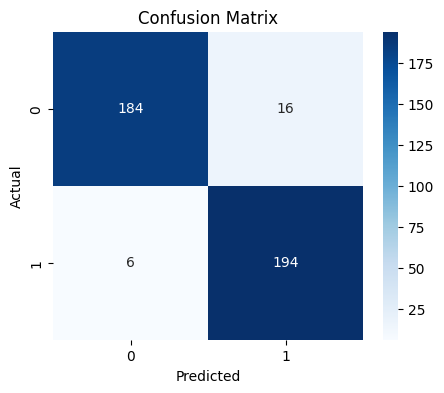

Classification Report:
               precision    recall  f1-score   support

      Normal       0.97      0.92      0.94       200
     Anomaly       0.92      0.97      0.95       200

    accuracy                           0.94       400
   macro avg       0.95      0.95      0.94       400
weighted avg       0.95      0.94      0.94       400



In [ ]:
import torch
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report
import seaborn as sns
import matplotlib.pyplot as plt

quantized_model_int8.eval()

with torch.no_grad():
    logits = quantized_model_int8(X_test_tensor)

    logits = logits.view(-1)
    y_true = y_test_tensor.view(-1).int()

    probs = torch.sigmoid(logits)

    y_pred = (probs > best_threshold).int()

acc = accuracy_score(y_true.numpy(), y_pred.numpy())
print(f"Test Accuracy: {acc*100:.2f}%")

cm = confusion_matrix(y_true.numpy(), y_pred.numpy())
print("Confusion Matrix:")
print(cm)

plt.figure(figsize=(5,4))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.show()

report = classification_report(
    y_true.numpy(),
    y_pred.numpy(),
    target_names=["Normal", "Anomaly"]
)
print("Classification Report:\n", report)

In [ ]:
torch.save(quantized_model_int8.state_dict(), "mlp_model_int8.pth")
print('Size (KB):', os.path.getsize("mlp_model_int8.pth")/1e3)

Size (KB): 23.405
